# IA708 — Notebook 2 : Modèle de base (Baseline)
## Régression logistique from scratch avec Adam

**Télécom Paris — Mastère IA Multimodale, 2026**

---

### Objectif de ce notebook

Construire un **modèle de référence** (baseline) pour la classification du risque crédit,
en implémentant tout from scratch (sans scikit-learn).

On couvre :
1. Préparation des données (split stratifié + prétraitement)
2. Théorie complète de la régression logistique
3. Optimiseur Adam : dérivation et implémentation
4. Sélection du seuil optimal (Youden/Balanced Accuracy)
5. Métriques de performance : AUC ROC, Balanced Accuracy, ECE
6. Visualisations : courbe ROC, matrice de confusion, calibration

---

### Pourquoi la régression logistique ?

On aurait pu utiliser un gradient boosting (XGBoost, LightGBM) qui donnerait probablement
une meilleure AUC. On choisit la régression logistique pour trois raisons :

1. **Interprétabilité** : les coefficients ont une signification directe (log-odds),
   et les valeurs SHAP sont **exactes** (pas d'approximation)
2. **Équité** : il est plus facile d'auditer un modèle linéaire et de comprendre
   d'où vient un biais
3. **Suffisant** : sur 1000 exemples, la capacité additionnelle des arbres
   est limitée


---
## 0. Setup : chargement et préparation des données

Cette section reprend rapidement les étapes de `nb_01_exploration.ipynb`.
Elle est nécessaire pour que ce notebook soit **autonome**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

# ── Chargement des données ────────────────────────────────────────────────────
COLUMNS = [
    "checking_status", "duration_in_month", "credit_history", "purpose",
    "credit_amount", "savings_account_bonds", "present_employment_since",
    "installment_rate", "personal_status_sex", "other_debtors_guarantors",
    "present_residence_since", "property", "age_in_years",
    "other_installment_plans", "housing", "number_of_existing_credits",
    "job", "number_of_people_liable", "telephone", "foreign_worker",
    "raw_target",
]

LABEL_MAP = {
    "checking_status": {"A11": "solde < 0 DM", "A12": "0 ≤ solde < 200 DM",
                        "A13": "solde ≥ 200 DM", "A14": "pas de compte courant"},
    "credit_history": {"A30": "aucun crédit ou tous remboursés", "A31": "tous crédits banque remboursés",
                       "A32": "crédits existants remboursés", "A33": "retards passés",
                       "A34": "compte critique"},
    "purpose": {"A40": "voiture (neuve)", "A41": "voiture (occasion)", "A42": "meubles",
                "A43": "radio/TV", "A44": "électroménager", "A45": "réparations",
                "A46": "éducation", "A47": "vacances", "A48": "reconversion",
                "A49": "business", "A410": "autres"},
    "savings_account_bonds": {"A61": "épargne < 100 DM", "A62": "100 ≤ épargne < 500 DM",
                              "A63": "500 ≤ épargne < 1000 DM", "A64": "épargne ≥ 1000 DM",
                              "A65": "inconnu / pas d'épargne"},
    "present_employment_since": {"A71": "sans emploi", "A72": "< 1 an",
                                  "A73": "1–4 ans", "A74": "4–7 ans", "A75": "≥ 7 ans"},
    "personal_status_sex": {"A91": "homme, divorcé/séparé", "A92": "femme, divorcée/mariée",
                            "A93": "homme, célibataire", "A94": "homme, marié/veuf",
                            "A95": "femme, célibataire"},
    "other_debtors_guarantors": {"A101": "aucun", "A102": "co-demandeur", "A103": "garant"},
    "property": {"A121": "immobilier", "A122": "épargne logement / assurance-vie",
                 "A123": "voiture ou autre", "A124": "inconnu / pas de propriété"},
    "other_installment_plans": {"A141": "banque", "A142": "magasins", "A143": "aucun"},
    "housing": {"A151": "locataire", "A152": "propriétaire", "A153": "hébergé gratuitement"},
    "job": {"A171": "sans emploi / non qualifié non-résident", "A172": "non qualifié résident",
            "A173": "employé qualifié", "A174": "management / hautement qualifié"},
    "telephone": {"A191": "aucun", "A192": "oui (au nom du client)"},
    "foreign_worker": {"A201": "oui", "A202": "non"},
}

raw = pd.read_csv("data/raw/german.data", sep=r"\s+", header=None, names=COLUMNS)
for col, mapping in LABEL_MAP.items():
    raw[col] = raw[col].astype(str).map(mapping).fillna(raw[col].astype(str))
raw["default"] = (raw["raw_target"] == 2).astype(int)

GENDER_MAP = {
    "homme, divorcé/séparé": "male", "homme, célibataire": "male",
    "homme, marié/veuf": "male",
    "femme, divorcée/mariée": "female", "femme, célibataire": "female",
}
raw["gender"]    = raw["personal_status_sex"].map(GENDER_MAP).fillna("unknown")
raw["age_group"] = np.where(raw["age_in_years"] >= 25, "older", "younger")

sensitive = {"gender": raw["gender"].values, "age": raw["age_group"].values}
PRIVILEGED = {"gender": "male", "age": "older"}

features = raw.drop(columns=[
    "raw_target", "default", "personal_status_sex", "age_in_years",
    "gender", "age_group"
])

NUMERIC = ["duration_in_month", "credit_amount", "installment_rate",
           "present_residence_since", "number_of_existing_credits",
           "number_of_people_liable"]
CATEG = [c for c in features.columns if c not in NUMERIC]
y = raw["default"].values

print(f"Dataset : {raw.shape[0]} individus, {features.shape[1]} features")
print(f"Taux de défaut : {y.mean():.1%}")


Dataset : 1000 individus, 18 features
Taux de défaut : 30.0%


---
## 1. Split stratifié

### Pourquoi stratifier ?

Avec un taux de défaut de ~30%, un split aléatoire sur 1000 exemples peut donner
des splits avec 25% ou 35% de défauts par pur hasard. Cela biaise les métriques
de fairness calculées sur les groupes sensibles (qui sont encore plus petits).

La **stratification** garantit que chaque split (train/val/test) a le même ratio 70/30
que le dataset original. On l'implémente **par classe** (label 0 et label 1 séparément).

**Proportions :** 60% train / 20% validation / 20% test
- La **validation** sert à : sélectionner le seuil optimal, monitorer l'early stopping
- Le **test** sert uniquement à l'évaluation finale (on n'y touche pas pendant l'entraînement)


In [2]:
rng = np.random.default_rng(42)

def stratified_split(y, ratios=(0.6, 0.2, 0.2)):
    """Split stratifié : préserve la distribution de y dans chaque subset."""
    idx_train, idx_val, idx_test = [], [], []
    for label in np.unique(y):
        ix = np.flatnonzero(y == label)
        rng.shuffle(ix)
        n = len(ix)
        n_tr = int(round(n * ratios[0]))
        n_va = int(round(n * ratios[1]))
        idx_train.extend(ix[:n_tr])
        idx_val.extend(ix[n_tr:n_tr + n_va])
        idx_test.extend(ix[n_tr + n_va:])
    return np.array(idx_train), np.array(idx_val), np.array(idx_test)

tr, va, te = stratified_split(y)

# Vérification de la stratification
print(f"{'Split':<10} {'N':>5} {'Taux défaut':>13}")
for name, idx in [("Train", tr), ("Val", va), ("Test", te)]:
    print(f"{name:<10} {len(idx):>5} {y[idx].mean():>13.1%}")

Split          N   Taux défaut
Train        600         30.0%
Val          200         30.0%
Test         200         30.0%


---
## 2. Prétraitement

### Z-score (features numériques)

$$x'_j = \frac{x_j - \mu_j}{\sigma_j}$$

où $\mu_j$ et $\sigma_j$ sont calculés **uniquement sur le train** (jamais sur val/test).
Cela évite le **data leakage** : si on utilisait la moyenne du test, le modèle
aurait implicitement vu les données de test avant l'évaluation.

La normalisation est nécessaire pour Adam : des features sur des échelles très différentes
(ex. `credit_amount` en milliers vs `installment_rate` entre 1 et 4) causent des gradients
de magnitudes très différentes, ralentissant la convergence.

### One-hot encoding (features catégorielles)

La régression logistique ne peut pas traiter des valeurs comme `"locataire"`, `"propriétaire"`
directement. On les convertit en colonnes binaires :
- `housing_locataire` : 1 si locataire, 0 sinon
- `housing_propriétaire` : 1 si propriétaire, 0 sinon
- etc.

Les niveaux sont appris sur le train uniquement. Les niveaux inconnus en test sont ignorés.


In [3]:
class Preprocessor:
    """Z-score (numériques) + one-hot encoding (catégoriels), fit sur train uniquement."""

    def fit(self, df):
        # Statistiques numériques (train seulement)
        self.num_means = df[NUMERIC].astype(float).mean()
        self.num_stds  = df[NUMERIC].astype(float).std(ddof=1).replace(0, 1)
        # Niveaux catégoriels (train seulement)
        self.cat_levels = {}
        self.dummy_cols = {}
        for c in CATEG:
            vals = sorted(df[c].astype(str).unique())
            self.cat_levels[c] = vals
            self.dummy_cols[c] = [f"{c}_{v}" for v in vals]
        self.feature_names = list(NUMERIC)
        for c in CATEG:
            self.feature_names.extend(self.dummy_cols[c])
        return self

    def transform(self, df):
        parts = []
        # Z-score
        num = (df[NUMERIC].astype(float) - self.num_means) / self.num_stds
        parts.append(num.reset_index(drop=True))
        # One-hot
        for c in CATEG:
            cat = pd.Categorical(df[c].astype(str), categories=self.cat_levels[c])
            dum = pd.get_dummies(cat, prefix=c, dtype=float)
            dum = dum.reindex(columns=self.dummy_cols[c], fill_value=0.0)
            parts.append(dum.reset_index(drop=True))
        out = pd.concat(parts, axis=1)
        out.columns = self.feature_names
        return out.values

prep = Preprocessor().fit(features.iloc[tr])
X_tr = prep.transform(features.iloc[tr])
X_va = prep.transform(features.iloc[va])
X_te = prep.transform(features.iloc[te])
y_tr, y_va, y_te = y[tr], y[va], y[te]

print(f"Dimension encodée : {X_tr.shape[1]} features (vs {features.shape[1]} originales)")
print(f"→ Expansion due au one-hot : {X_tr.shape[1] - features.shape[1]} colonnes ajoutées")

Dimension encodée : 56 features (vs 18 originales)
→ Expansion due au one-hot : 38 colonnes ajoutées


---
## 3. Théorie : Régression logistique

### Modèle

On modélise la probabilité de défaut par :

$$P(Y=1 \mid x) = \sigma(w^\top x + b) = \frac{1}{1 + e^{-(w^\top x + b)}}$$

où $\sigma$ est la **fonction sigmoïde** qui transforme n'importe quelle valeur réelle en une probabilité dans $[0, 1]$.

### Fonction de perte : log-vraisemblance binaire (BCE)

On maximise la vraisemblance des labels observés, ce qui revient à minimiser la **Binary Cross-Entropy** :

$$\mathcal{L}(w, b) = -\frac{1}{n} \sum_{i=1}^{n} \alpha_i \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right] + \frac{\lambda}{2} \|w\|^2$$

Le terme $\frac{\lambda}{2} \|w\|^2$ est la **régularisation L2** (Ridge) qui pénalise les coefficients trop grands
→ réduit le surapprentissage sur les 600 exemples d'entraînement.

### Gradients

$$\frac{\partial \mathcal{L}}{\partial w} = \frac{1}{n}X^\top\big((\hat{p}-y)\odot \alpha\big) + \lambda w$$

$$\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n}\sum_i (\hat{p}_i - y_i)\,\alpha_i$$

où $\alpha_i$ sont les **poids d'échantillon** (utiles pour le reweighing dans le notebook 3).

Note de notation : $w$ désigne toujours les **poids du modèle**, et $\alpha_i$ les **poids d'exemple**.



---
## 4. Théorie : Optimiseur Adam

On n'utilise pas le gradient descent classique (SGD) mais **Adam** (Adaptive Moment Estimation, Kingma & Ba 2015).

### Pourquoi Adam ?

- Le SGD classique utilise le même taux d'apprentissage pour tous les paramètres
- Les features one-hot sont **sparse** (la plupart à 0) : leurs gradients sont souvent nuls,
  puis soudainement grands → un taux global inadapté
- Adam adapte le taux d'apprentissage **par paramètre** grâce aux moments

### Algorithme Adam

À chaque étape $t$, pour le gradient $g_t$ :

$$m_t = \beta_1 \cdot m_{t-1} + (1-\beta_1) \cdot g_t \quad \text{(premier moment : moyenne mobile)}$$

$$v_t = \beta_2 \cdot v_{t-1} + (1-\beta_2) \cdot g_t^2 \quad \text{(second moment : variance mobile)}$$

Correction du biais (car $m_0 = v_0 = 0$) :

$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

Mise à jour :

$$\theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

**Intuition** : $m_t$ est la direction (tendance), $\sqrt{v_t}$ est l'amplitude des variations.
On divise par $\sqrt{v_t}$ pour réduire le pas sur les paramètres qui oscillent beaucoup
et l'augmenter sur ceux qui bougent peu.

**Paramètres utilisés** : $\alpha=0.03$, $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$, $\lambda=0.01$


### Glossaire des variables (formules)

| Symbole | Correspondance | A quoi ca sert |
|---|---|---|
| $x_j$ | Valeur brute de la feature numerique $j$ | Point de depart avant normalisation |
| $x'_j$ | Valeur normalisee (z-score) | Met toutes les features a une echelle comparable |
| $\mu_j$ | Moyenne train de la feature $j$ | Centre la feature pour le z-score |
| $\sigma_j$ | Ecart-type train de la feature $j$ | Met a l'echelle dans le z-score |
| $x$ | Vecteur de features d'un individu | Entree du modele |
| $X$ | Matrice des features (tous les individus) | Calcul vectorise du training et des gradients |
| $Y$ / $y_i$ | Label reel (`1` defaut, `0` non-defaut) | Cible supervisee |
| $\hat{p}_i$ | Probabilite predite de defaut pour l'exemple $i$ | Score de risque utilise pour la decision |
| $w$ | Coefficients du modele | Poids de chaque feature dans les log-odds |
| $b$ | Biais (intercept) | Decale globalement la prediction |
| $\sigma(\cdot)$ | Fonction sigmoide | Transforme les log-odds en probabilite |
| $\mathcal{L}(w,b)$ | Fonction de perte (BCE + L2) | Objectif a minimiser pendant l'entrainement |
| $\alpha_i$ | Poids d'exemple (sample weight) | Re-pondere certains exemples (utile pour fairness) |
| $\lambda$ | Coefficient de regularisation L2 | Evite des poids trop grands (limite le sur-apprentissage) |
| $n$ | Nombre d'exemples | Normalise perte et gradients |
| $g_t$ | Gradient au pas $t$ | Direction de mise a jour des parametres |
| $m_t, v_t$ | Moments Adam (1er et 2e) | Stabilisent et adaptent la descente |
| $\hat{m}_t, \hat{v}_t$ | Moments corriges du biais | Corrigent l'initialisation a zero |
| $\beta_1, \beta_2$ | Decroissance des moyennes mobiles Adam | Reglent l'inertie des moments |
| $\alpha$ | Learning rate Adam | Taille du pas de mise a jour |
| $\epsilon$ | Terme de stabilite numerique Adam | Evite la division par zero |
| $\theta_t$ | Parametre au pas $t$ | Valeur actuelle des poids/biais |
| $t$ | Seuil de decision | Convertit les probabilites en classes 0/1 |
| $TP, FP, TN, FN$ | Cases de matrice de confusion | Base des metriques de classification |
| $TPR, TNR$ | Taux de vrais positifs / vrais negatifs | Composantes de la balanced accuracy |
| $s_i$ | Score pour l'exemple $i$ (AUC) | Sert au classement positif vs negatif |
| $n_+, n_-$ | Nombre de positifs / negatifs | Normalisation de la formule AUC |
| $B, \mathcal{B}_b$ | Nombre de bins et bin $b$ (ECE) | Decoupage des probabilites pour evaluer la calibration |
| $\mathrm{acc}(\mathcal{B}_b)$ | Taux reel de positifs dans le bin $b$ | Compare prediction et realite |
| $\mathrm{conf}(\mathcal{B}_b)$ | Confiance moyenne predite dans le bin $b$ | Niveau moyen de probabilite annonce |


In [4]:
def sigmoid(z):
    """Sigmoïde numériquement stable : évite overflow avec clip."""
    return 1 / (1 + np.exp(-np.clip(z, -50, 50)))

def train_logreg(X, y, X_val, y_val, lr=0.03, l2=0.01, epochs=3500,
                 patience=300, sample_weight=None):
    """
    Régression logistique entraînée avec Adam.

    Paramètres
    ----------
    X, y          : données d'entraînement
    X_val, y_val  : données de validation (pour early stopping)
    lr            : taux d'apprentissage Adam
    l2            : coefficient de régularisation L2
    epochs        : nombre maximum d'époques
    patience      : nombre d'époques sans amélioration avant l'arrêt
    sample_weight : poids par exemple (pour reweighing, cf. notebook 3)

    Retourne
    --------
    (w, b, history) : poids, biais, historique de val loss
    """
    n, d = X.shape

    # Initialisation : w=0, b=log(p/(1-p)) avec p = taux de défaut train
    w = np.zeros(d)
    p0 = np.clip(y.mean(), 1e-4, 1-1e-4)
    b  = float(np.log(p0 / (1 - p0)))

    # Poids d'échantillon normalisés
    sw = np.ones(n) if sample_weight is None else sample_weight * (n / sample_weight.sum())

    # État Adam (moments pour w et b)
    mw, vw = np.zeros(d), np.zeros(d)
    mb, vb = 0.0, 0.0

    # Variables pour early stopping
    best_w, best_b, best_loss = w.copy(), b, np.inf
    stale = 0
    history = []

    for ep in range(1, epochs + 1):
        # ── Forward pass ──────────────────────────────────────────────────────
        p_hat = sigmoid(X @ w + b)         # probabilités prédites
        err   = (p_hat - y) * sw           # erreur pondérée

        # ── Gradients ─────────────────────────────────────────────────────────
        gw = X.T @ err / n + l2 * w        # gradient w (avec L2)
        gb = err.mean()                    # gradient b (pas de L2 sur le biais)

        # ── Mise à jour Adam ──────────────────────────────────────────────────
        # Premiers moments
        mw = 0.9 * mw + 0.1 * gw
        vw = 0.999 * vw + 0.001 * gw**2
        mb = 0.9 * mb + 0.1 * gb
        vb = 0.999 * vb + 0.001 * gb**2
        # Correction du biais
        mwh = mw / (1 - 0.9**ep)
        vwh = vw / (1 - 0.999**ep)
        mbh = mb / (1 - 0.9**ep)
        vbh = vb / (1 - 0.999**ep)
        # Mise à jour des paramètres
        w -= lr * mwh / (np.sqrt(vwh) + 1e-8)
        b -= lr * mbh / (np.sqrt(vbh) + 1e-8)

        # ── Monitoring sur validation ─────────────────────────────────────────
        p_val    = sigmoid(X_val @ w + b)
        val_loss = -np.mean(
            y_val * np.log(np.clip(p_val, 1e-8, 1-1e-8)) +
            (1 - y_val) * np.log(np.clip(1 - p_val, 1e-8, 1-1e-8))
        )
        history.append(val_loss)

        # ── Early stopping ────────────────────────────────────────────────────
        if val_loss + 1e-6 < best_loss:    # amélioration significative
            best_loss = val_loss
            best_w, best_b = w.copy(), b
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                break

    return best_w, best_b, history

print("Fonctions définies : sigmoid, train_logreg")

Fonctions définies : sigmoid, train_logreg


---
## 5. Entraînement du modèle baseline


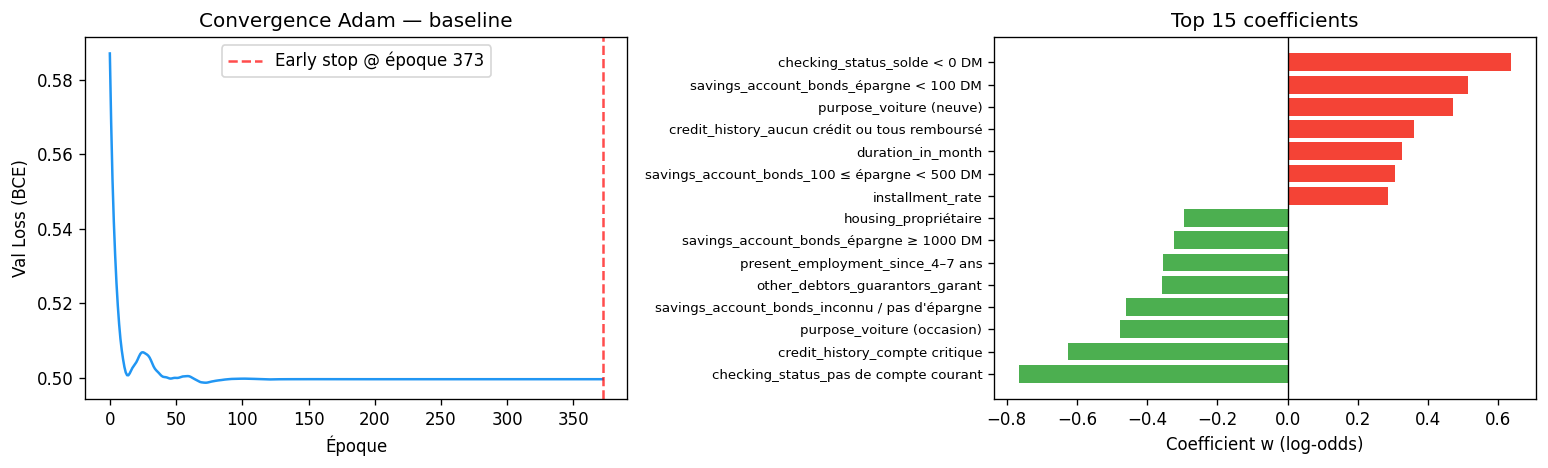

Entraînement terminé après 373 époques
Biais (b) = -1.1978  →  P(défaut) si x=0 : 23.2%


In [5]:
w_base, b_base, hist_base = train_logreg(X_tr, y_tr, X_va, y_va)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Courbe de convergence (val loss)
axes[0].plot(hist_base, color="#2196F3", linewidth=1.5)
axes[0].axvline(len(hist_base)-1, color="red", linestyle="--", alpha=0.7,
                label=f"Early stop @ époque {len(hist_base)}")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Val Loss (BCE)")
axes[0].set_title("Convergence Adam — baseline")
axes[0].legend()

# Distribution des coefficients (top 15 en valeur absolue)
coef_df = pd.DataFrame({"feature": prep.feature_names, "coef": w_base})
top_coef = coef_df.reindex(coef_df["coef"].abs().nlargest(15).index).sort_values("coef")
colors_c = ["#f44336" if v > 0 else "#4CAF50" for v in top_coef["coef"]]
axes[1].barh(range(len(top_coef)), top_coef["coef"].values, color=colors_c)
axes[1].set_yticks(range(len(top_coef)))
axes[1].set_yticklabels([f[:45] for f in top_coef["feature"]], fontsize=8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Coefficient w (log-odds)")
axes[1].set_title("Top 15 coefficients")

plt.tight_layout()
plt.show()

print(f"Entraînement terminé après {len(hist_base)} époques")
print(f"Biais (b) = {b_base:.4f}  →  P(défaut) si x=0 : {sigmoid(b_base):.1%}")

---
## 6. Sélection du seuil optimal

Un classificateur binaire prédit $\hat{y} = \mathbf{1}[P(Y=1|x) \geq t]$ pour un seuil $t$.
La valeur par défaut $t=0.5$ est arbitraire et souvent sous-optimale avec des classes déséquilibrées.

### Critère : Balanced Accuracy (Youden's index)

$$\text{BalAcc}(t) = \frac{1}{2} \left( \text{TPR}(t) + \text{TNR}(t) \right)
= \frac{1}{2} \left( \frac{TP}{TP+FN} + \frac{TN}{TN+FP} \right)$$

On maximise cette quantité sur la **validation** (jamais sur le test !).

**Pourquoi pas l'accuracy ?**
Un modèle naïf qui prédit toujours "bon payeur" obtient 70% d'accuracy sur ce dataset
mais 50% de Balanced Accuracy (il ne détecte aucun défaut).
La Balanced Accuracy équilibre la détection des deux classes.


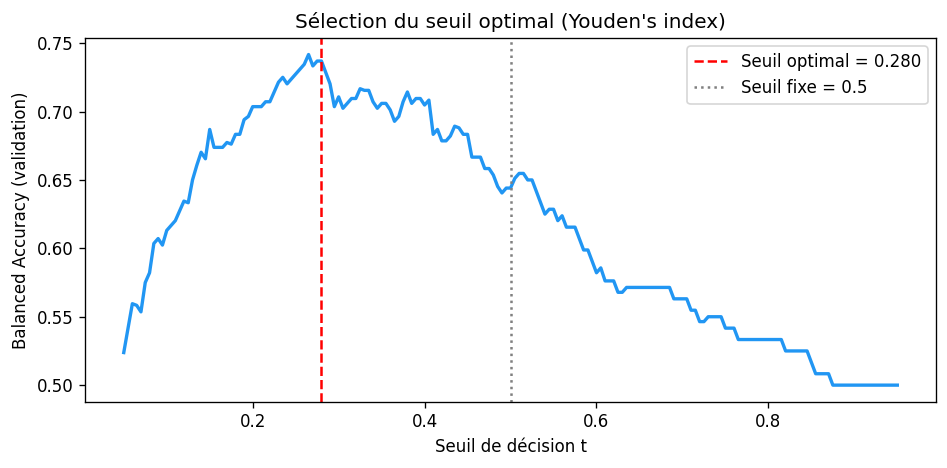

Seuil optimal (val) : 0.280
→ Le modèle prédit défaut si P(Y=1|x) ≥ 0.280


In [6]:
def predict_scores(X, w, b):
    return sigmoid(X @ w + b)

def best_threshold(y_true, scores, n_candidates=81):
    """Seuil qui maximise la Balanced Accuracy (Youden's index)."""
    best_t, best_ba = 0.5, 0.0
    for t in np.linspace(0.1, 0.9, n_candidates):
        pred = (scores >= t).astype(int)
        tp = ((pred==1) & (y_true==1)).sum()
        tn = ((pred==0) & (y_true==0)).sum()
        pos, neg = (y_true==1).sum(), (y_true==0).sum()
        ba = 0.5 * (tp/max(pos,1) + tn/max(neg,1))
        if ba > best_ba:
            best_ba, best_t = ba, t
    return best_t

# Scores sur validation et test
scores_va = predict_scores(X_va, w_base, b_base)
scores_te = predict_scores(X_te, w_base, b_base)

# Seuil sélectionné sur validation
thr_base = best_threshold(y_va, scores_va)

# Visualisation de la Balanced Accuracy en fonction du seuil
thresholds = np.linspace(0.05, 0.95, 181)
ba_vals = []
for t in thresholds:
    pred = (scores_va >= t).astype(int)
    tp = ((pred==1) & (y_va==1)).sum()
    tn = ((pred==0) & (y_va==0)).sum()
    pos, neg = (y_va==1).sum(), (y_va==0).sum()
    ba_vals.append(0.5 * (tp/max(pos,1) + tn/max(neg,1)))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, ba_vals, color="#2196F3", linewidth=2)
plt.axvline(thr_base, color="red", linestyle="--",
            label=f"Seuil optimal = {thr_base:.3f}")
plt.axvline(0.5, color="gray", linestyle=":", label="Seuil fixe = 0.5")
plt.xlabel("Seuil de décision t")
plt.ylabel("Balanced Accuracy (validation)")
plt.title("Sélection du seuil optimal (Youden's index)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Seuil optimal (val) : {thr_base:.3f}")
print(f"→ Le modèle prédit défaut si P(Y=1|x) ≥ {thr_base:.3f}")

---
## 7. Métriques de performance

### AUC ROC

L'**AUC ROC** (Area Under the Receiver Operating Characteristic Curve) mesure la capacité
du modèle à discriminer les deux classes, **indépendamment du seuil**.

Elle est calculée ici via la **statistique de Wilcoxon-Mann-Whitney** :

$$\text{AUC} = \frac{\sum_{i: y_i=1} \text{rank}(s_i) - n_+ (n_+ + 1)/2}{n_+ \cdot n_-}$$

Interprétation : AUC = probabilité qu'un individu positif ait un score supérieur à un négatif.

### ECE (Expected Calibration Error)

La **calibration** mesure si les probabilités prédites correspondent à des fréquences réelles.
Si le modèle dit "70% de chance de défaut", est-ce que ~70% des individus avec ce score font défaut ?

$$\text{ECE} = \sum_{b=1}^{B} \frac{|\mathcal{B}_b|}{n} \left| \text{acc}(\mathcal{B}_b) - \text{conf}(\mathcal{B}_b) \right|$$

Un ECE proche de 0 est bien calibré. La régression logistique est connue pour être
naturellement bien calibrée (contrairement aux forêts aléatoires ou aux SVMs).


In [7]:
def confusion(y, pred):
    tp = ((pred==1) & (y==1)).sum()
    fp = ((pred==1) & (y==0)).sum()
    tn = ((pred==0) & (y==0)).sum()
    fn = ((pred==0) & (y==1)).sum()
    return tp, fp, tn, fn

def auc_roc(y, scores):
    """AUC via Wilcoxon-Mann-Whitney — O(n log n)."""
    pos, neg = (y==1).sum(), (y==0).sum()
    if pos == 0 or neg == 0:
        return float("nan")
    ranks = pd.Series(scores).rank(method="average").values
    return (ranks[y==1].sum() - pos*(pos+1)/2) / (pos * neg)

def ece(y, scores, n_bins=10):
    """Expected Calibration Error."""
    bins = np.linspace(0, 1, n_bins+1)
    total = 0.0
    for i in range(n_bins):
        if i < n_bins - 1:
            mask = (scores >= bins[i]) & (scores < bins[i+1])
        else:
            mask = (scores >= bins[i])
        if mask.sum() == 0:
            continue
        total += mask.sum() / len(y) * abs(y[mask].mean() - scores[mask].mean())
    return total

def eval_model(y, preds, scores):
    """Calcule toutes les métriques de performance."""
    tp, fp, tn, fn = confusion(y, preds)
    tpr = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    precision = tp / max(tp + fp, 1)
    f1 = 2 * precision * tpr / max(precision + tpr, 1e-8)
    return {
        "AUC": auc_roc(y, scores),
        "BalAcc": 0.5 * (tpr + tnr),
        "F1": f1,
        "ECE": ece(y, scores),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "TPR": tpr, "TNR": tnr, "Precision": precision
    }

# Évaluation du baseline sur le test set
preds_base = (scores_te >= thr_base).astype(int)
perf = eval_model(y_te, preds_base, scores_te)

print("=== Performance baseline (test set) ===")
print(f"  AUC ROC        : {perf['AUC']:.4f}")
print(f"  Balanced Acc   : {perf['BalAcc']:.4f}")
print(f"  F1             : {perf['F1']:.4f}")
print(f"  ECE            : {perf['ECE']:.4f}")
print(f"  Seuil utilisé  : {thr_base:.3f}")
print(f"\n  Matrice de confusion :")
print(f"    TP={perf['TP']}  FP={perf['FP']}")
print(f"    FN={perf['FN']}  TN={perf['TN']}")
print(f"\n  TPR (rappel)   : {perf['TPR']:.4f}  (% de défauts détectés)")
print(f"  TNR (spécif.)  : {perf['TNR']:.4f}  (% de bons payeurs préservés)")
print(f"  Précision      : {perf['Precision']:.4f}  (% correct parmi prédits positifs)")

=== Performance baseline (test set) ===
  AUC ROC        : 0.7932
  Balanced Acc   : 0.7012
  F1             : 0.5850
  ECE            : 0.0575
  Seuil utilisé  : 0.280

  Matrice de confusion :
    TP=43  FP=44
    FN=17  TN=96

  TPR (rappel)   : 0.7167  (% de défauts détectés)
  TNR (spécif.)  : 0.6857  (% de bons payeurs préservés)
  Précision      : 0.4943  (% correct parmi prédits positifs)


---
## 8. Visualisations : ROC, matrice de confusion, calibration


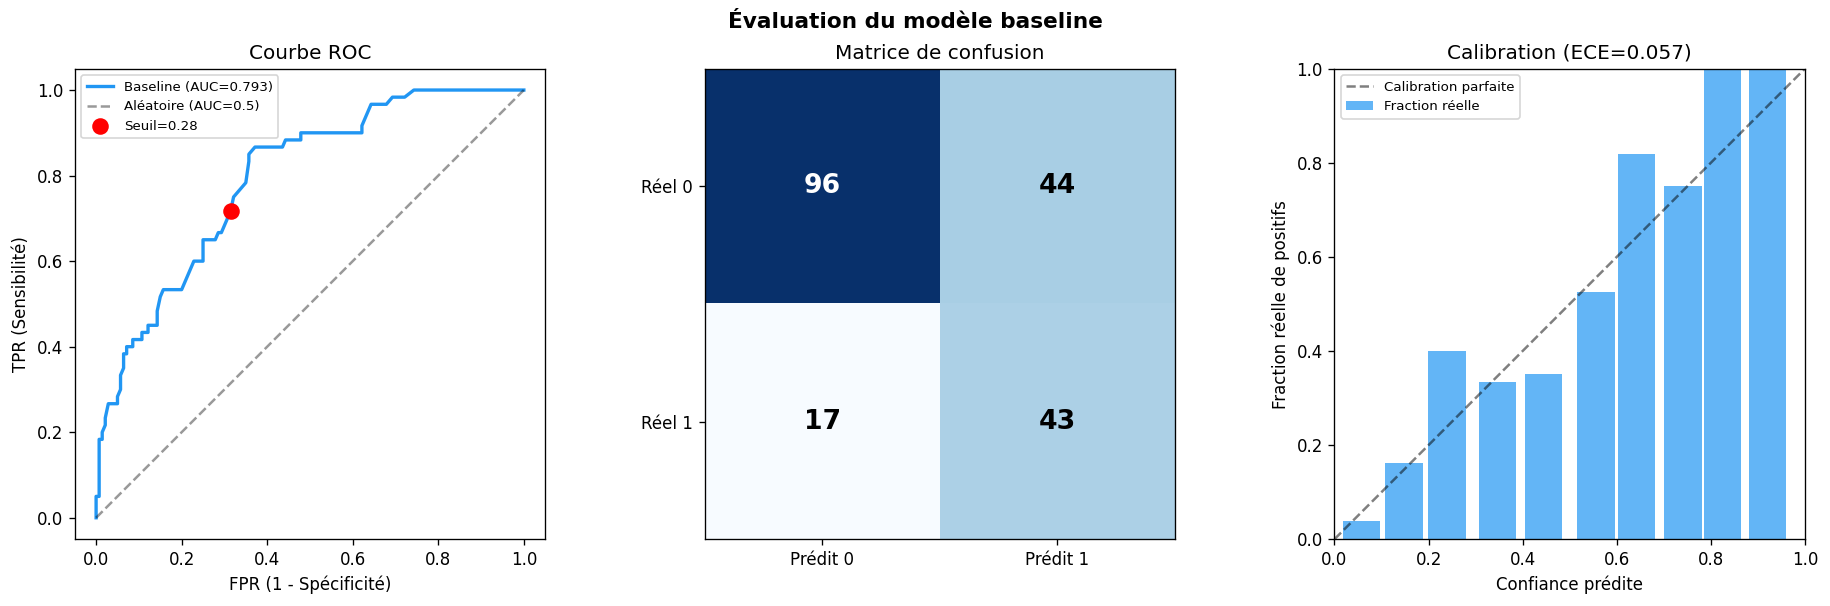

In [8]:
# ── Courbe ROC ────────────────────────────────────────────────────────────────
def roc_curve_points(y, scores, n_pts=200):
    """Calcule les points (FPR, TPR) de la courbe ROC."""
    thresholds = np.linspace(0, 1, n_pts)
    fprs, tprs = [], []
    pos, neg = (y==1).sum(), (y==0).sum()
    for t in thresholds:
        pred = (scores >= t).astype(int)
        tp = ((pred==1) & (y==1)).sum()
        fp = ((pred==1) & (y==0)).sum()
        tprs.append(tp / max(pos, 1))
        fprs.append(fp / max(neg, 1))
    return np.array(fprs), np.array(tprs)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Courbe ROC
fpr, tpr = roc_curve_points(y_te, scores_te)
axes[0].plot(fpr, tpr, color="#2196F3", linewidth=2, label=f"Baseline (AUC={perf['AUC']:.3f})")
axes[0].plot([0,1], [0,1], "k--", alpha=0.4, label="Aléatoire (AUC=0.5)")
# Point au seuil optimal
pred_t = (scores_te >= thr_base).astype(int)
tp_t = ((pred_t==1) & (y_te==1)).sum()
fp_t = ((pred_t==1) & (y_te==0)).sum()
axes[0].scatter(fp_t/(y_te==0).sum(), tp_t/(y_te==1).sum(),
                color="red", s=80, zorder=5, label=f"Seuil={thr_base:.2f}")
axes[0].set_xlabel("FPR (1 - Spécificité)")
axes[0].set_ylabel("TPR (Sensibilité)")
axes[0].set_title("Courbe ROC")
axes[0].legend(fontsize=8)
axes[0].set_aspect("equal")

# Matrice de confusion
cm = np.array([[perf["TN"], perf["FP"]], [perf["FN"], perf["TP"]]])
im = axes[1].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center",
                     fontsize=16, fontweight="bold",
                     color="white" if cm[i,j] > cm.max()/2 else "black")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Prédit 0", "Prédit 1"])
axes[1].set_yticklabels(["Réel 0", "Réel 1"])
axes[1].set_title("Matrice de confusion")

# Diagramme de calibration
n_bins = 10
bins = np.linspace(0, 1, n_bins+1)
bin_centers, fracs, confs = [], [], []
for i in range(n_bins):
    if i < n_bins-1:
        mask = (scores_te >= bins[i]) & (scores_te < bins[i+1])
    else:
        mask = (scores_te >= bins[i])
    if mask.sum() == 0:
        continue
    bin_centers.append(scores_te[mask].mean())
    fracs.append(y_te[mask].mean())
    confs.append(scores_te[mask].mean())

axes[2].bar(bin_centers, fracs, width=0.08, alpha=0.7, color="#2196F3", label="Fraction réelle")
axes[2].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Calibration parfaite")
axes[2].set_xlabel("Confiance prédite")
axes[2].set_ylabel("Fraction réelle de positifs")
axes[2].set_title(f"Calibration (ECE={perf['ECE']:.3f})")
axes[2].legend(fontsize=8)
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].set_aspect("equal")

plt.suptitle("Évaluation du modèle baseline", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 9. Conclusion

### Résultats du baseline

Le modèle de régression logistique atteint :
- **AUC ROC ≈ 0.79** : bonne discrimination, bien au-dessus du hasard (0.5)
- **Balanced Accuracy ≈ 0.71** : bon équilibre entre détection des défauts et préservation des bons payeurs
- **ECE < 0.06** : bien calibré, les probabilités prédites sont fiables

### Ce qu'on ne sait pas encore

Ces métriques sont **globales** : elles ne disent rien sur :
- Le traitement différentiel entre hommes et femmes
- Le traitement différentiel entre jeunes et âgés
- Quelles variables influencent les prédictions
- La stabilité du modèle sous bruit

→ **Notebook 3** : mesure et correction du biais (équité)

→ **Notebook 4** : interprétabilité (SHAP, proxies, permutation importance)

→ **Notebook 5** : robustesse (perturbations, stabilité des métriques, calibration)
